<font style="font-family:roboto;color:#455e6c;font-size:18px;text-align:justify"> <b> Analyze data with paraprobe-toolbox <br> </b> </font>
The paraprobe-toolbox is a collection of algorithms that bring performant implementations of algorithms from the field of computational geometry to the field of atom probe tomography. Each tool is an own parallelized application that is tailored to perform specific computational geometry or analysis tasks. These tools can be chained into workflows that are fully customizable, as it is shown in this example. Again the silicon specimen that was already discussed in the CompositionSpace tutorial is taken as a fast demo dataset. Further details about paraprobe-toolbox were summarized by M. Kühbach et al. [here](https://arxiv.org/abs/2205.13510). The results are stored in an HDF5 file whose groups, fields, and attributes follow the semantics of the [NeXus](https://www.github.com/FAIRmat-NFDI/nexus_definitions) data model for the configuration files used and the results obtained with each tool of the paraprobe-toolbox. The science that is in this analysis workflow is discussed in further detail [here](https://gitlab.com/paraprobe/paraprobe-toolbox/-/blob/main/teaching/example_analyses/usa_denton_smith).

In [2]:
from pyiron_workflow import Workflow
from nodes.paraprobe import *

In [3]:
wf = Workflow("demo")
wf.transcoder = transcoder_job()
wf.ranger = ranger_job(wf.transcoder)
wf.ranger_reporter = ranger_reporter(wf.ranger)
wf.surfacer = surfacer_job(wf.transcoder, wf.ranger)
wf.distancer = distancer_job(wf.transcoder, wf.ranger, wf.surfacer)
#wf.distancer_reporter = distancer_reporter(wf.distancer)
wf.tessellator = tessellator_job(wf.transcoder, wf.ranger)
wf.tessellator_reporter = tessellator_reporter(wf.tessellator)
wf.center = get_center(wf.transcoder)
wf.selector = selector_job(wf.transcoder, wf.ranger, wf.center)
wf.selector_reporter = selector_reporter(wf.selector)
wf.spatstat = spatstat_job(wf.transcoder, wf.ranger, wf.distancer)
wf.nanochem = nanochem_job(wf.transcoder, wf.ranger, wf.surfacer, wf.distancer)
wf.nanochem_report = nanochem_reporter(wf.nanochem)

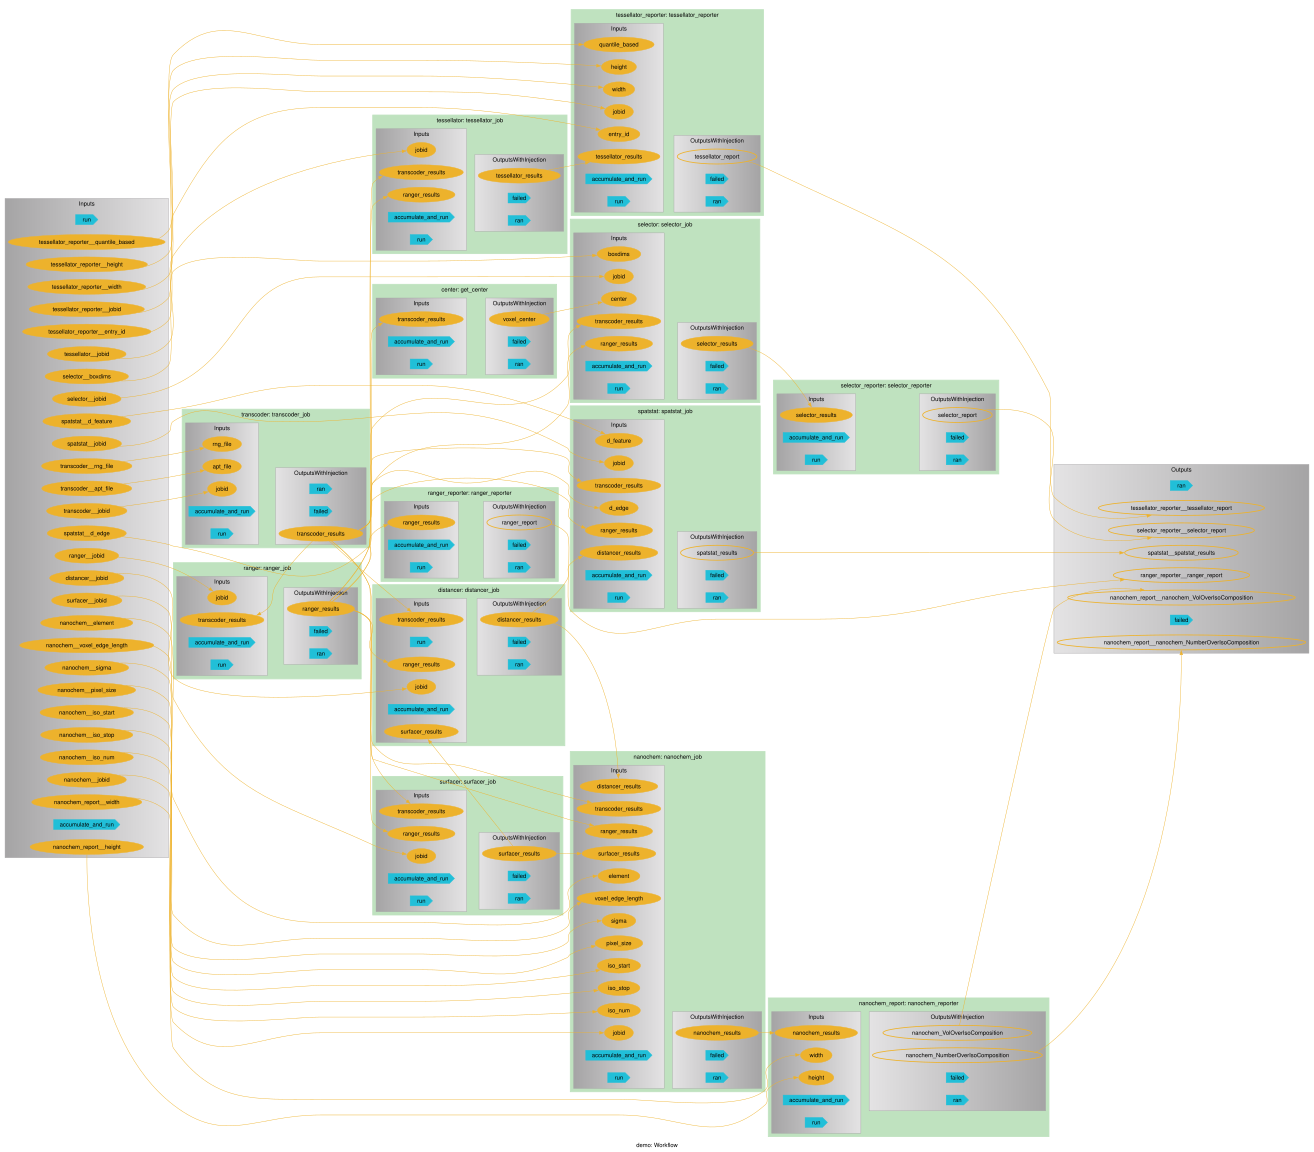

In [5]:
wf.draw(size=(16 * 2, 8 * 2))

In [6]:
wf.run()

Computing SHA256 hash for file named Si.apt
Computing SHA256 hash for file named Si.RNG
Inspecting whether NeXus/HDF5 is used...
The reconstruction and ranging come from files of technology
partners but the paraprobe-toolbox uses NeXus/HDF5.
Hence, paraprobe-transcoder will transcode to NeXus/HDF5.
Writing configuration file ...
PARAPROBE.Transcoder.Config.SimID.1.nxs was written successfully
/entry1/transcode/reconstruction/path, /entry1/transcode/ranging/path
True
Processing configuration file: PARAPROBE.Transcoder.Config.SimID.1.nxs
Processing reconstruction: Si.apt
Processing ranging: Si.RNG
Results file: PARAPROBE.Transcoder.Results.SimID.1.nxs
Input reconstruction and ranging definitions use files from
technology partners (POS, ePOS, APT, RRNG, RNG) or other
file formats from the community. These will be transcoded to NeXus...
Computing SHA256 hash for file named PARAPROBE.Transcoder.Config.SimID.1.nxs
Reading Si.apt which is 37810040 B
File describes 945211 ions
Currently at byt


libgomp: Invalid value for environment variable OMP_NUM_THREADS: 


Rank 0 initialized, we are now MPI_COMM_WORLD parallel using MPI_THREAD_FUNNELED
Adding iontype ...
id 1
charge 2+
isotope vector 
14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
mass-to-charge ranges.size() 1

Adding iontype ...
id 2
charge 1+
isotope vector 
14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
mass-to-charge ranges.size() 1

Adding iontype ...
id 3
charge 1+
isotope vector 
24, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
mass-to-charge ranges.size() 1

Adding iontype ...
id 4
charge 1+
isotope vector 
14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
mass-to-charge ranges.size() 1

Adding iontype ...
id 5
charge 1+
isotope vector 
14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
mass-to-charge ranges.size() 1

Adding iontype ...


HDF5-DIAG: Error detected in HDF5 (1.14.3) MPI-process 0:
  #000: H5F.c line 836 in H5Fopen(): unable to synchronously open file
    major: File accessibility
    minor: Unable to open file
  #001: H5F.c line 796 in H5F__open_api_common(): unable to open file
    major: File accessibility
    minor: Unable to open file
  #002: H5VLcallback.c line 3863 in H5VL_file_open(): open failed
    major: Virtual Object Layer
    minor: Can't open object
  #003: H5VLcallback.c line 3675 in H5VL__file_open(): open failed
    major: Virtual Object Layer
    minor: Can't open object
  #004: H5VLnative_file.c line 128 in H5VL__native_file_open(): unable to open file
    major: File accessibility
    minor: Unable to open file
  #005: H5Fint.c line 1851 in H5F_open(): unable to open file: name = '/home/kaiobach/Research/hu_hu_hu/sprint26/iuc09_dfg_demo/pyiron_apt/PARAPROBE.Distancer.Results.SimID.1.nxs', tent_flags = 0
    major: File accessibility
    minor: Unable to open file
  #006: H5FD.c line 76

Thread 0 took 13.9506 s, nvertices_cur 0 nfacets_cur 0
Rank 0 hybrid tessellating took 13.9675 seconds
sizeof(unsigned char) 1
Packing boolean states stored in unsigned char into a bitfield
8 bits in an unsigned char
in.size() 945211
byte_length 118152
out.size() 118152
sizeof(unsigned char) 1
Packing boolean states stored in unsigned char into a bitfield
8 bits in an unsigned char
in.size() 945211
byte_length 118152
out.size() 118152
sizeof(unsigned char) 1
Packing boolean states stored in unsigned char into a bitfield
8 bits in an unsigned char
in.size() 945211
byte_length 118152
out.size() 118152
sizeof(unsigned char) 1
Packing boolean states stored in unsigned char into a bitfield
8 bits in an unsigned char
in.size() 945211
byte_length 118152
out.size() 118152
sizeof(unsigned char) 1
Packing boolean states stored in unsigned char into a bitfield
8 bits in an unsigned char
in.size() 945211
byte_length 118152
out.size() 118152
sizeof(unsigned char) 1
Packing boolean states stored in 

...

Rank 0 identifying closed polyhedra for isovalue 0.0199999995529651641845703125 was successful
Written objects properties successfully
Rank 0 writing object properties for isovalue 0.0199999995529651641845703125 was successful
Calculating which ions are inside which object
We detected eventual truncation of object by the edge of the dataset via evaluating the closest ion to the edge
The threshold distance used is 1 nm
Vdiscretized about the reconstructed volume 177284 nm^3
Ion inclusion tests took 0.046660484000085489242337644100189 seconds
Sorting ion_evap arrays for convenience took 0.0037765879999369644792750477790833 seconds
Rank 0 identified which ions are in which closed polyhedron
Rank 0 writing ions inside polyhedra for isovalue 0.0199999995529651641845703125 was successful
Rank 0 writing object geometries for isovalue 0.0199999995529651641845703125 was successful
Rank 0 processes iso-surfacing task ...
Iso-surfacing tasklist
taskid 1
gridid 1
dlzid 1
isrfid 3
deloc_method reso

Watertight model: yes, volume is 11369.494148051760930684395134449 nm^3, checking watertightness took 0.015632380000170087441802024841309 seconds
Double 11369.494148051760930684395134449 Int 0
Rank 0 writing triangle soup for isovalue 0.02999999932944774627685546875 was successful
triangleSoupClustering::build_triangles_rtree thread 0 rtree built, took 0.0059446199993544723838567733764648 seconds
triangleSoupClustering::build_triangle_rtree was successful
A total of 106 connected regions were found
Rank 0 identifying connected regions with tri_eps 0.001000000047497451305389404296875 was successful
Rank 0 writing object IDs for tri_eps 0.001000000047497451305389404296875 for isovalue 0.02999999932944774627685546875 was successful
Rank 0 identifying closed polyhedra for isovalue 0.02999999932944774627685546875 was successful
Written objects properties successfully
Rank 0 writing object properties for isovalue 0.02999999932944774627685546875 was successful
Calculating which ions are insid

Rank 0 identifying closed polyhedra for isovalue 0.039999999105930328369140625 was successful
Written objects properties successfully
Rank 0 writing object properties for isovalue 0.039999999105930328369140625 was successful
Calculating which ions are inside which object
We detected eventual truncation of object by the edge of the dataset via evaluating the closest ion to the edge
The threshold distance used is 1 nm
Vdiscretized about the reconstructed volume 177284 nm^3
Ion inclusion tests took 0.033445330999938960303552448749542 seconds
Sorting ion_evap arrays for convenience took 0.0034549249999145104084163904190063 seconds
Rank 0 identified which ions are in which closed polyhedron
Rank 0 writing ions inside polyhedra for isovalue 0.039999999105930328369140625 was successful
Rank 0 writing object geometries for isovalue 0.039999999105930328369140625 was successful
Rank 0 processes iso-surfacing task ...
Iso-surfacing tasklist
taskid 1
gridid 1
dlzid 1
isrfid 5
deloc_method resolve_

Rank 0 identifying closed polyhedra for isovalue 0.0500000007450580596923828125 was successful
Written objects properties successfully
Rank 0 writing object properties for isovalue 0.0500000007450580596923828125 was successful
Calculating which ions are inside which object
We detected eventual truncation of object by the edge of the dataset via evaluating the closest ion to the edge
The threshold distance used is 1 nm
Vdiscretized about the reconstructed volume 177284 nm^3
Ion inclusion tests took 0.034251333999918642803095281124115 seconds
Sorting ion_evap arrays for convenience took 0.0034945739998875069431960582733154 seconds
Rank 0 identified which ions are in which closed polyhedron
Rank 0 writing ions inside polyhedra for isovalue 0.0500000007450580596923828125 was successful
Rank 0 writing object geometries for isovalue 0.0500000007450580596923828125 was successful
characterize_local_chemistry took on rank 0 took 11.335035451000067041604779660702
Rank 0 left MPI_COMM_WORLD decon

{'ranger_reporter__ranger_report': None,
 'tessellator_reporter__tessellator_report': <IPython.core.display.Image object>,
 'selector_reporter__selector_report': None,
 'spatstat__spatstat_results': 'PARAPROBE.Spatstat.Results.SimID.1.nxs',
 'nanochem_report__nanochem_VolOverIsoComposition': <IPython.core.display.Image object>,
 'nanochem_report__nanochem_NumberOverIsoComposition': <IPython.core.display.Image object>}

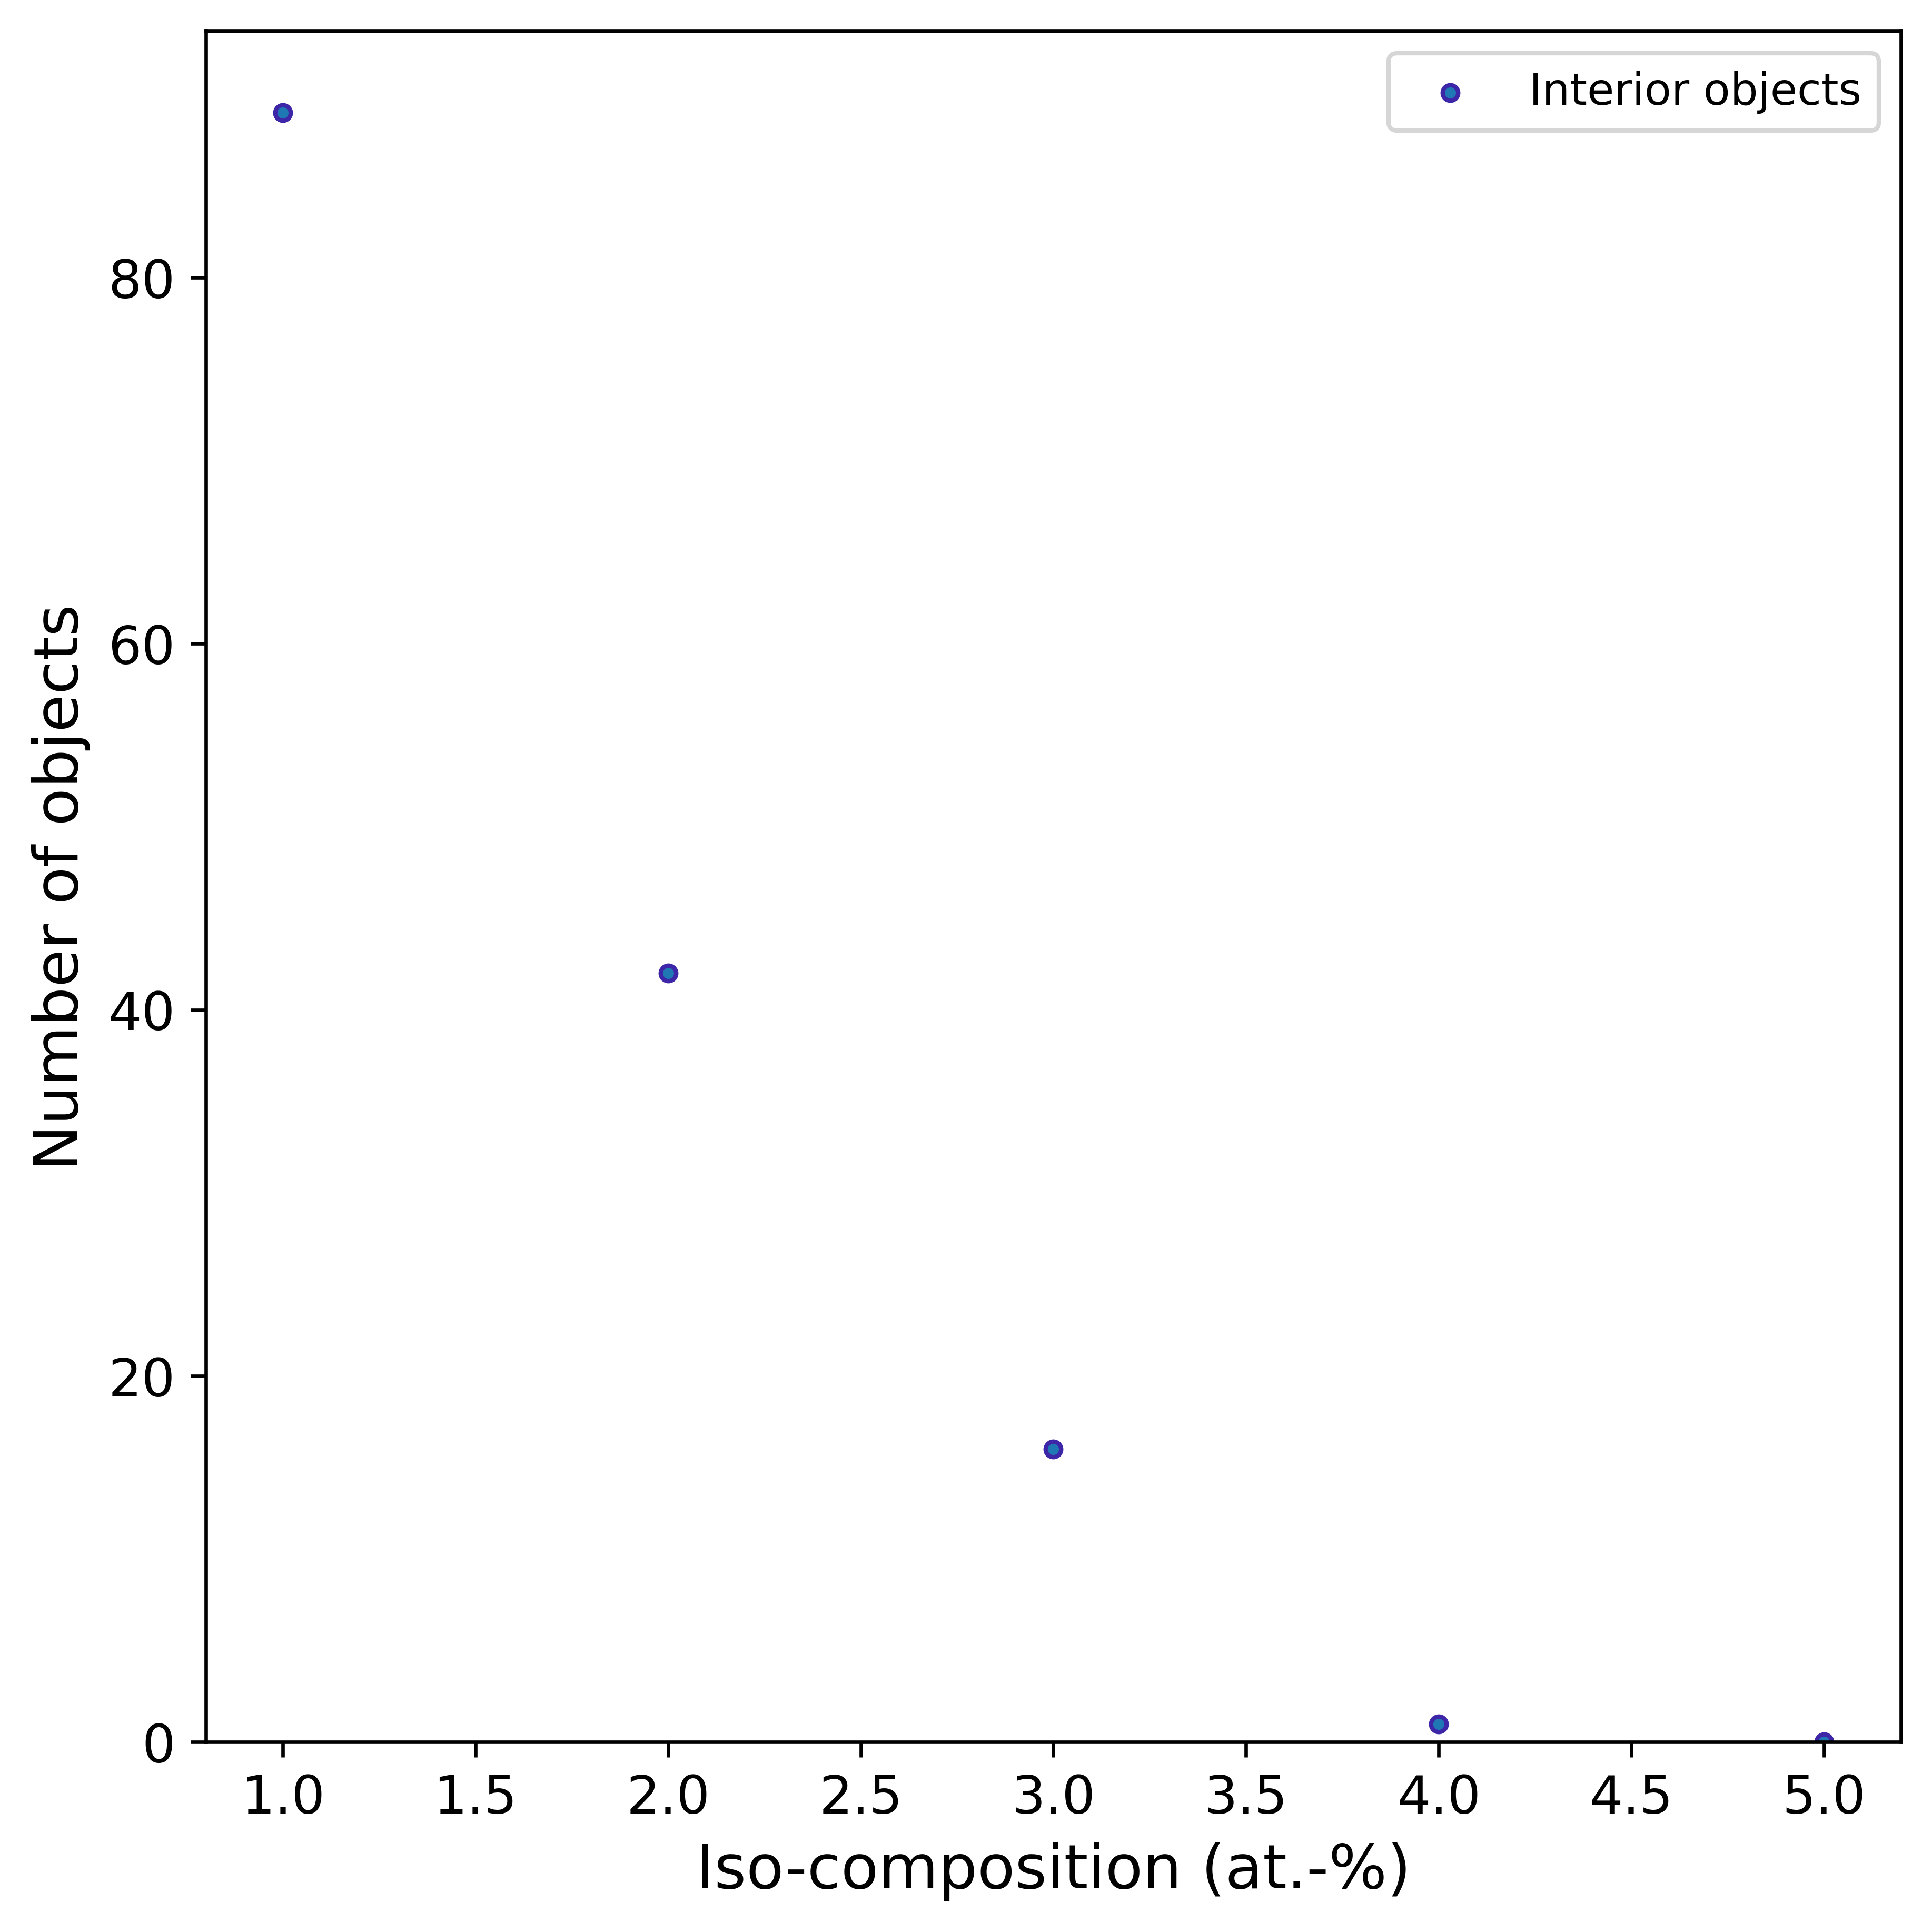

In [7]:
wf.outputs.nanochem_report__nanochem_NumberOverIsoComposition.value